In [1]:
import pandas as pd
import os

# 1. kaggle.jsonをアップロード
from google.colab import files
if not os.path.exists("kaggle.json"):
    files.upload()

# 2. Kaggle APIの設定（フォルダ作成と権限付与）
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 3. Spaceship Titanic データのダウンロード
!kaggle competitions download -c spaceship-titanic

# 4. zipファイルの解凍
import zipfile
with zipfile.ZipFile('spaceship-titanic.zip', 'r') as zip_ref:
    zip_ref.extractall()

# 5. データの読み込み
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("読み込み完了")

Saving kaggle.json to kaggle.json
100% 299k/299k [00:00<00:00, 647kB/s]

読み込み完了


In [2]:
# データの概要表示
display(train.head())

# データ型と欠損値の確認
print("\n--- Train Info ---")
train.info()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True



--- Train Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


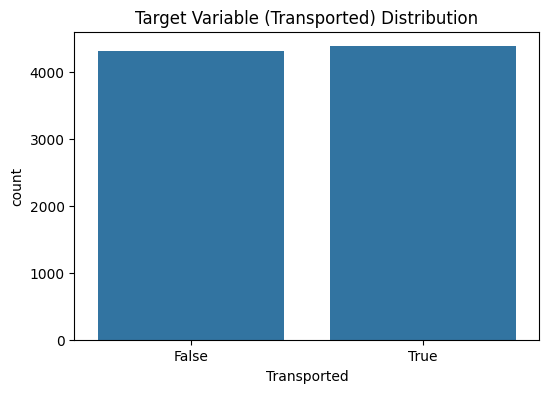

Transported
True     0.503624
False    0.496376
Name: proportion, dtype: float64


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# ターゲットの分布を可視化
plt.figure(figsize=(6, 4))
sns.countplot(x='Transported', data=train)
plt.title('Target Variable (Transported) Distribution')
plt.show()

# 数値で確認
print(train['Transported'].value_counts(normalize=True))

In [4]:
# 欠損値の数と割合を確認
missing = train.isnull().sum()
missing_pct = (train.isnull().sum() / len(train)) * 100
missing_df = pd.concat([missing, missing_pct], axis=1, keys=['Total', 'Percent'])
print(missing_df.sort_values(by='Total', ascending=False))

              Total   Percent
CryoSleep       217  2.496261
ShoppingMall    208  2.392730
VIP             203  2.335212
HomePlanet      201  2.312205
Name            200  2.300702
Cabin           199  2.289198
VRDeck          188  2.162660
Spa             183  2.105142
FoodCourt       183  2.105142
Destination     182  2.093639
RoomService     181  2.082135
Age             179  2.059128
PassengerId       0  0.000000
Transported       0  0.000000


In [5]:
import numpy as np

import pandas as pd
import numpy as np

# 1. 前準備：グループIDの抽出と支出合計の計算
for df in [train, test]:
    # PassengerId (XXXX_YY) からグループID (XXXX) を抽出
    df['Group'] = df['PassengerId'].apply(lambda x: x.split('_')[0])
    # 支出系の列
    exp_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    # 支出合計を一時的に作成（補完の判断材料にするため）
    df['TotalExp'] = df[exp_cols].sum(axis=1)

In [6]:
# 2. 支出系の補完（CryoSleepとの論理的整合性）
# コールドスリープ中の人は支出が0になるはず
exp_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
for df in [train, test]:
    for col in exp_cols:
        # CryoSleepがTrueなら支出は0で埋める
        df.loc[(df[col].isnull()) & (df['CryoSleep'] == True), col] = 0
        # それ以外は全体の中央値で埋める
        df[col] = df[col].fillna(df[col].median())
    # 支出補完後にTotalExpを更新
    df['TotalExp'] = df[exp_cols].sum(axis=1)

In [7]:
# 3. CryoSleepの補完
for df in [train, test]:
    # 1ドルでも使っている人は起きていた（CryoSleep=False）はず
    df.loc[(df['CryoSleep'].isnull()) & (df['TotalExp'] > 0), 'CryoSleep'] = False
    # それ以外は最頻値で埋める
    df['CryoSleep'] = df['CryoSleep'].fillna(df['CryoSleep'].mode()[0])

/tmp/ipykernel_10394/2780933322.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['CryoSleep'] = df['CryoSleep'].fillna(df['CryoSleep'].mode()[0])
/tmp/ipykernel_10394/2780933322.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['CryoSleep'] = df['CryoSleep'].fillna(df['CryoSleep'].mode()[0])


In [8]:
# 4. HomePlanet / Destination の補完（グループ内での類推）
for col in ['HomePlanet', 'Destination']:
    # グループごとの最頻値をマッピングする辞書を作成
    # 訓練データとテストデータを合わせた全データから類推
    combined = pd.concat([train, test])
    gp_map = combined.dropna(subset=[col]).groupby('Group')[col].apply(lambda x: x.mode()[0]).to_dict()

    for df in [train, test]:
        # 同じグループの人がいればその値を採用
        df[col] = df[col].fillna(df.Group.map(gp_map))
        # まだ残っている場合は全体の実績値の最頻値で埋める
        df[col] = df[col].fillna(df[col].mode()[0])

In [9]:
# 5. Ageの補完
for df in [train, test]:
    # 支出あり/なしのグループごとに年齢の中央値を計算して適用
    df['Age'] = df.groupby(df['TotalExp'] > 0)['Age'].transform(lambda x: x.fillna(x.median()))

In [10]:
# 6. VIPの補完
for df in [train, test]:
    df['VIP'] = df['VIP'].fillna(df['VIP'].mode()[0])

/tmp/ipykernel_10394/1624334173.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['VIP'] = df['VIP'].fillna(df['VIP'].mode()[0])


In [11]:
print("--- 補完後の欠損値数 ---")
print(train.isnull().sum()[train.isnull().sum() > 0])

--- 補完後の欠損値数 ---
Cabin    199
Name     200
dtype: int64


In [12]:
for df in [train, test]:
    # 1. 欠損値を一旦 'Z/9999/Z' で置き換えて分割
    df['Cabin'] = df['Cabin'].fillna('Z/9999/Z')
    df['Cabin_deck'] = df['Cabin'].apply(lambda x: x.split('/')[0])
    df['Cabin_num']  = df['Cabin'].apply(lambda x: x.split('/')[1]).astype(int)
    df['Cabin_side'] = df['Cabin'].apply(lambda x: x.split('/')[2])

    # 2. グループ情報を使って 'Z' を補完
    combined = pd.concat([train, test])
    for col in ['Cabin_deck', 'Cabin_side']:
        # その列の 'Z' 以外のデータがある行だけでグループごとの最頻値を作る
        valid_data = combined[combined[col] != 'Z']

        # グループごとの最頻値を計算
        gp_series = valid_data.groupby('Group')[col].apply(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
        gp_map = gp_series.to_dict()

        # row（行）ごとに、Zならグループ情報で上書き
        df[col] = df.apply(lambda row: gp_map.get(row['Group'], row[col]) if row[col] == 'Z' else row[col], axis=1)

        # 3. それでも残った 'Z' を、全体の最頻値で埋める
        overall_mode_series = valid_data[col].mode()
        if not overall_mode_series.empty:
            overall_mode = overall_mode_series[0]
            df.loc[df[col] == 'Z', col] = overall_mode
        else:
            # 万が一全体が空なら適当な値を設定
            df.loc[df[col] == 'Z', col] = 'F' if col == 'Cabin_deck' else 'S'

# 最後に Cabin_num の 9999 を中央値に
train['Cabin_num'] = train['Cabin_num'].replace(9999, train['Cabin_num'].median())
test['Cabin_num'] = test['Cabin_num'].replace(9999, test['Cabin_num'].median())

In [13]:
for df in [train, test]:
    # 名字だけを抽出（欠損値は 'Unknown' に）
    df['Name'] = df['Name'].fillna('Unknown Unknown')
    df['Surname'] = df['Name'].apply(lambda x: x.split()[-1])

# 名字ごとに「家族が何人乗っているか」という新変数を作る
all_surnames = pd.concat([train['Surname'], test['Surname']])
surname_count = all_surnames.value_counts().to_dict()

for df in [train, test]:
    df['FamilySize'] = df['Surname'].map(surname_count)
    # Unknownは1人扱いにしておく
    df.loc[df['Surname'] == 'Unknown', 'FamilySize'] = 1

In [14]:
drop_cols = ['Cabin', 'Name', 'Group', 'Surname', 'TotalExp']
train.drop(columns=drop_cols, inplace=True)
test.drop(columns=drop_cols, inplace=True)

print("最終的な欠損値確認:")
print(train.isnull().sum().sum())

最終的な欠損値確認:
0


In [15]:
train['Group'] = train['PassengerId'].apply(lambda x: x.split('_')[0])
test['Group'] = test['PassengerId'].apply(lambda x: x.split('_')[0])

# グループごとの人数を計算
combined = pd.concat([train, test])
group_size = combined['Group'].value_counts().to_dict()

train['GroupSize'] = train['Group'].map(group_size)
test['GroupSize'] = test['Group'].map(group_size)

# 「一人旅かどうか」のフラグ
train['IsAlone'] = (train['GroupSize'] == 1).astype(int)
test['IsAlone'] = (test['GroupSize'] == 1).astype(int)

In [16]:
# 年齢を特定の区分で分ける
def age_group(age):
    if age <= 12: return 'Child'
    if age <= 18: return 'Teen'
    if age <= 50: return 'Adult'
    return 'Elderly'

train['AgeGroup'] = train['Age'].apply(age_group)
test['AgeGroup'] = test['Age'].apply(age_group)

In [17]:
exp_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# 支出合計を計算
train['TotalExp'] = train[exp_cols].sum(axis=1)
test['TotalExp'] = test[exp_cols].sum(axis=1)

# 「支出ゼロ」フラグ
train['NoSpending'] = (train['TotalExp'] == 0).astype(int)
test['NoSpending'] = (test['TotalExp'] == 0).astype(int)

In [18]:
# 学習に使わない列をリストアップ
drop_cols = ['Group']

train.drop(columns=drop_cols, inplace=True)
test.drop(columns=drop_cols, inplace=True)

display(train.head())

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,...,Transported,Cabin_deck,Cabin_num,Cabin_side,FamilySize,GroupSize,IsAlone,AgeGroup,TotalExp,NoSpending
0,0001_01,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,...,False,B,0,P,3,1,1,Adult,0.0,1
1,0002_01,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,...,True,F,0,S,4,1,1,Adult,736.0,0
2,0003_01,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,...,False,A,0,S,7,2,0,Elderly,10383.0,0
3,0003_02,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,...,False,A,0,S,7,2,0,Adult,5176.0,0
4,0004_01,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,...,True,F,1,S,9,1,1,Teen,1091.0,0


/tmp/ipykernel_10394/1935873386.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Transported', data=train, ax=axes[i], palette='viridis')
/tmp/ipykernel_10394/1935873386.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Transported', data=train, ax=axes[i], palette='viridis')
/tmp/ipykernel_10394/1935873386.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Transported', data=train, ax=axes[i], palette='viridis')
/tmp/ipykernel_10394/1935873386.py:13: FutureWarning: 

Passing `palette` without assigning

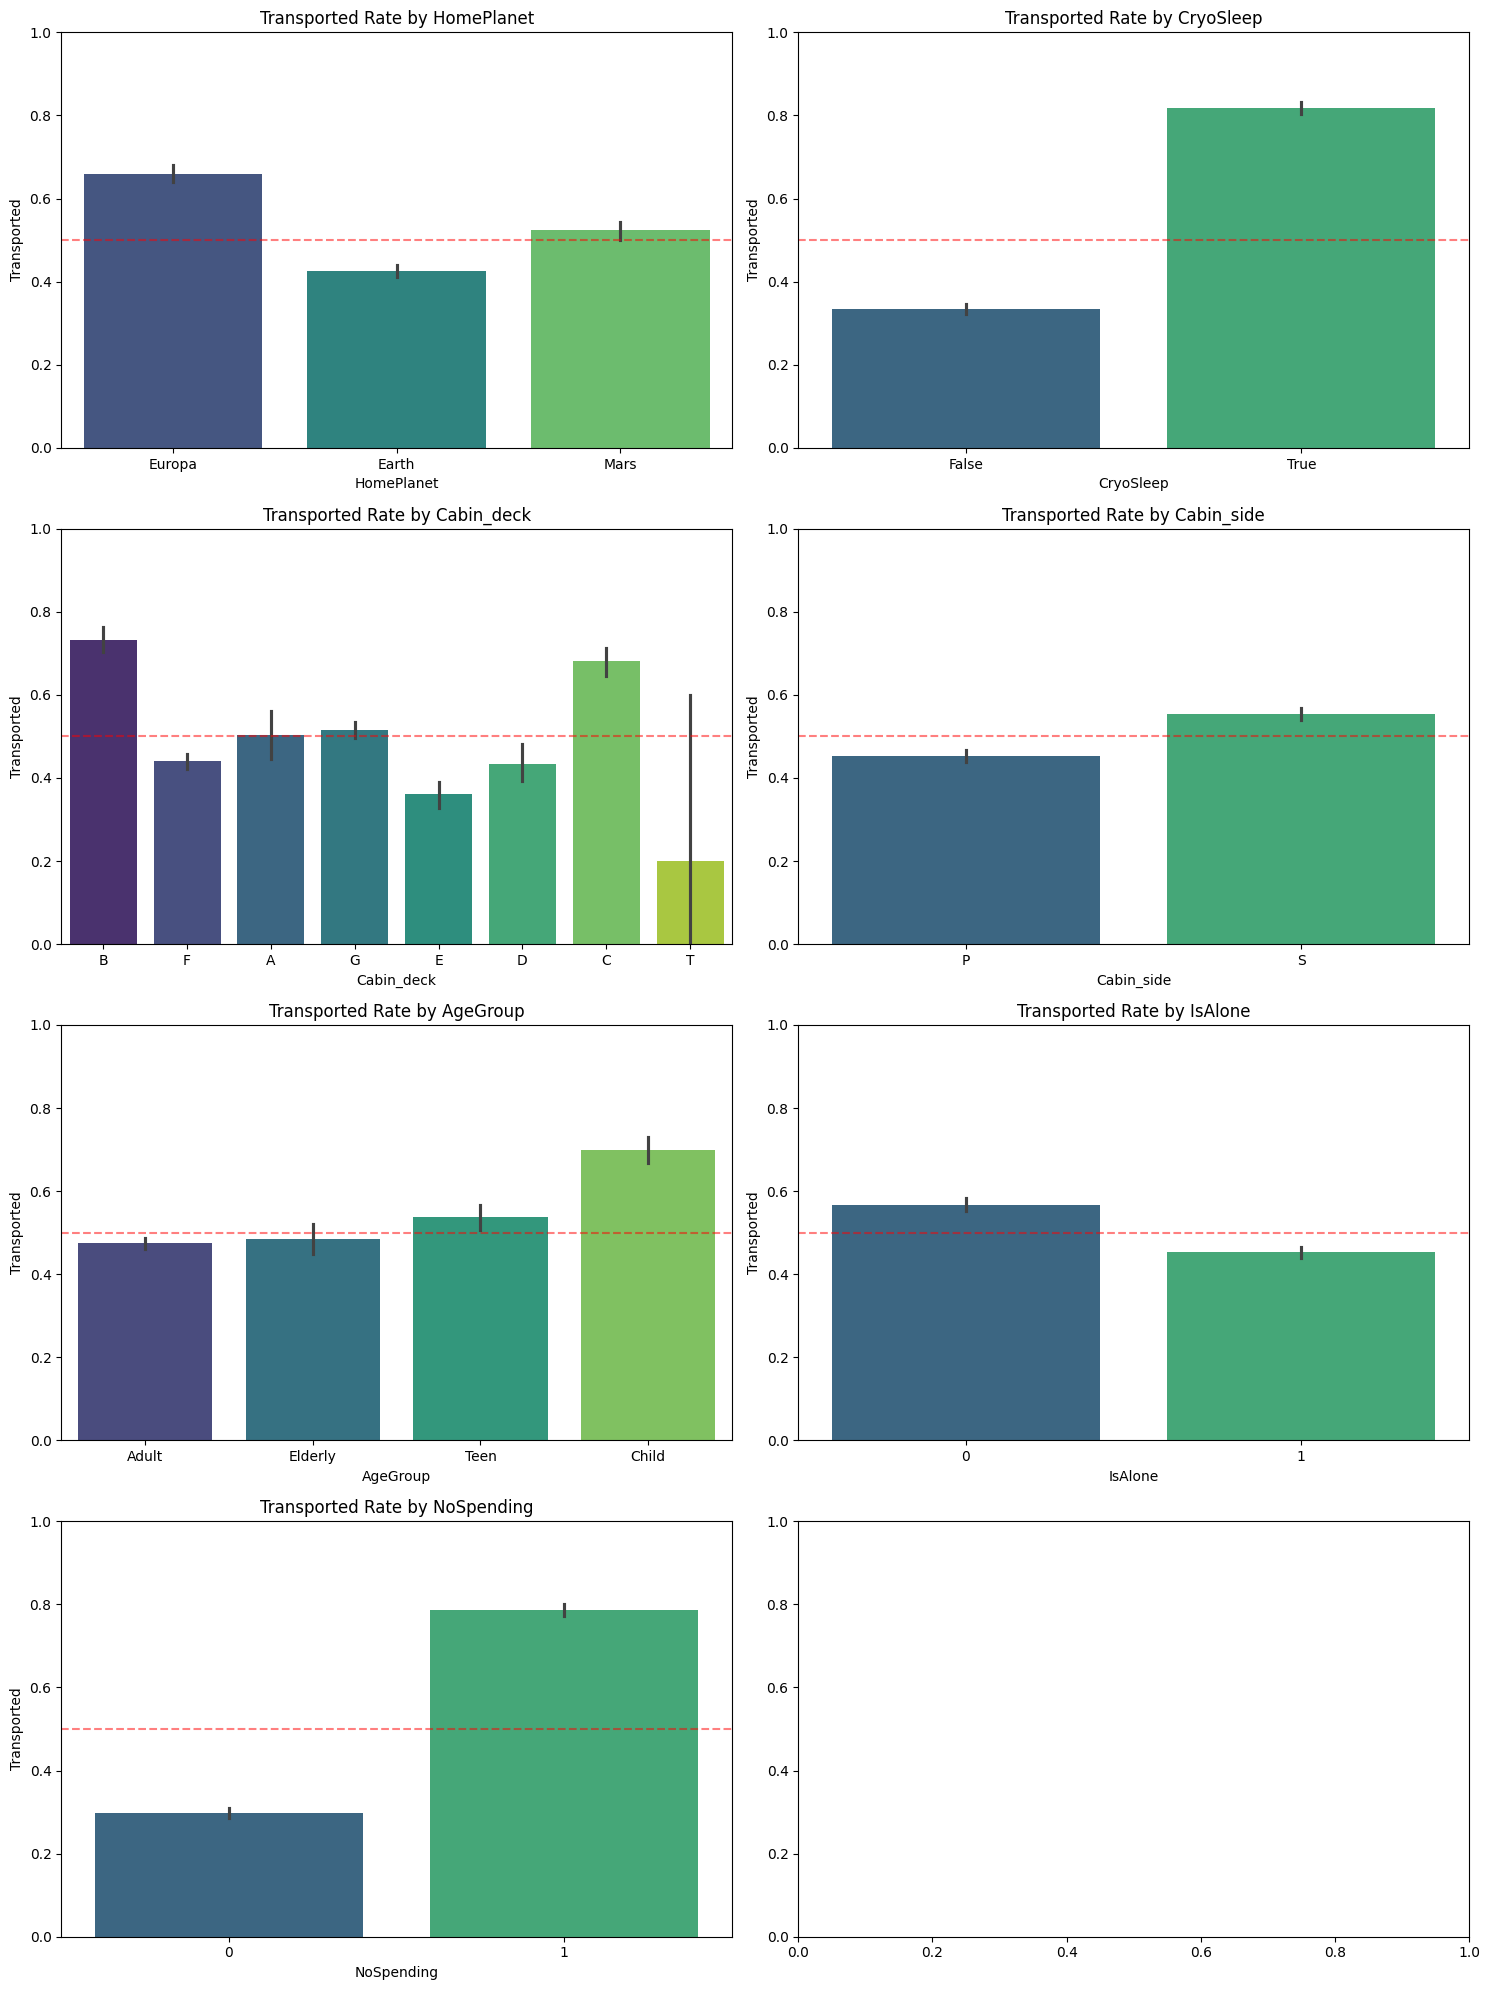

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 可視化したい特徴量のリスト
features = ['HomePlanet', 'CryoSleep', 'Cabin_deck', 'Cabin_side', 'AgeGroup', 'IsAlone', 'NoSpending']

# グラフのレイアウト設定（2列で並べる）
fig, axes = plt.subplots(round(len(features)/2), 2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(features):
    # 各カテゴリにおける Transported の割合をプロット
    sns.barplot(x=col, y='Transported', data=train, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Transported Rate by {col}')
    axes[i].set_ylim(0, 1) # 割合なので0~1に固定
    axes[i].axhline(0.5, ls='--', color='red', alpha=0.5) # 全体平均(約50%)の線

plt.tight_layout()
plt.show()

In [20]:
from sklearn.preprocessing import LabelEncoder

# 1. 順番に意味があるカテゴリを Label Encoding
le_cols = ['Cabin_deck', 'Cabin_side', 'AgeGroup']
for col in le_cols:
    le = LabelEncoder()
    # 訓練データとテストデータを合わせてフィットさせる
    le.fit(pd.concat([train[col], test[col]]))
    train[col] = le.transform(train[col])
    test[col] = le.transform(test[col])

# 2. 残りのカテゴリ変数を One-Hot Encoding
train = pd.get_dummies(train, columns=['HomePlanet', 'Destination', 'CryoSleep', 'VIP'], drop_first=True)
test = pd.get_dummies(test, columns=['HomePlanet', 'Destination', 'CryoSleep', 'VIP'], drop_first=True)

# bool型を整数（0, 1）に変換
train['Transported'] = train['Transported'].astype(int)

# 並び順を訓練データとテストデータで揃える
test = test[train.drop('Transported', axis=1).columns]

In [21]:
test_id = test['PassengerId']

# 学習に使わない列を削除
X = train.drop(['PassengerId', 'Transported'], axis=1)
y = train['Transported']
X_test = test.drop(['PassengerId'], axis=1)

print(f"学習データの形状: {X.shape}")
print(f"テストデータの形状: {X_test.shape}")

学習データの形状: (8693, 21)
テストデータの形状: (4277, 21)


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"訓練用: {X_train.shape}")
print(f"検証用: {X_val.shape}")

訓練用: (6954, 21)
検証用: (1739, 21)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/tmp/ipykernel_10394/1657126741.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coeffs, palette='coolwarm')


Accuracy (正解率): 0.7872

--- 分類レポート ---
              precision    recall  f1-score   support

           0       0.79      0.78      0.78       863
           1       0.78      0.80      0.79       876

    accuracy                           0.79      1739
   macro avg       0.79      0.79      0.79      1739
weighted avg       0.79      0.79      0.79      1739



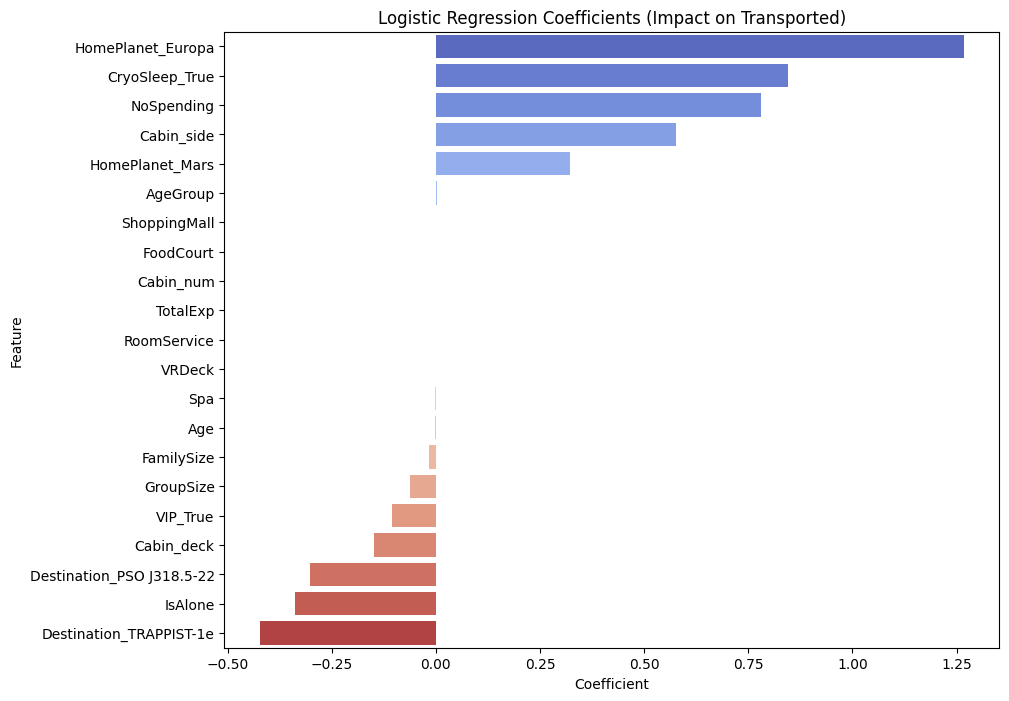

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. モデルの構築と学習
lr_model = LogisticRegression(max_iter=2000)
lr_model.fit(X_train, y_train)

# 2. 検証データで予測
y_pred = lr_model.predict(X_val)

# 3. 評価指標の表示
print(f"Accuracy (正解率): {accuracy_score(y_val, y_pred):.4f}")
print("\n--- 分類レポート ---")
print(classification_report(y_val, y_pred))

# 4. 特徴量の重み（係数）を可視化
coeffs = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr_model.coef_[0]})
coeffs = coeffs.sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Coefficient', y='Feature', data=coeffs, palette='coolwarm')
plt.title('Logistic Regression Coefficients (Impact on Transported)')
plt.show()

Decision Tree Accuracy: 0.7878

--- 特徴量の重要度 (Top 5) ---
         Feature  Importance
13      TotalExp    0.554766
2      FoodCourt    0.107431
6     Cabin_deck    0.087328
3   ShoppingMall    0.063957
4            Spa    0.053535


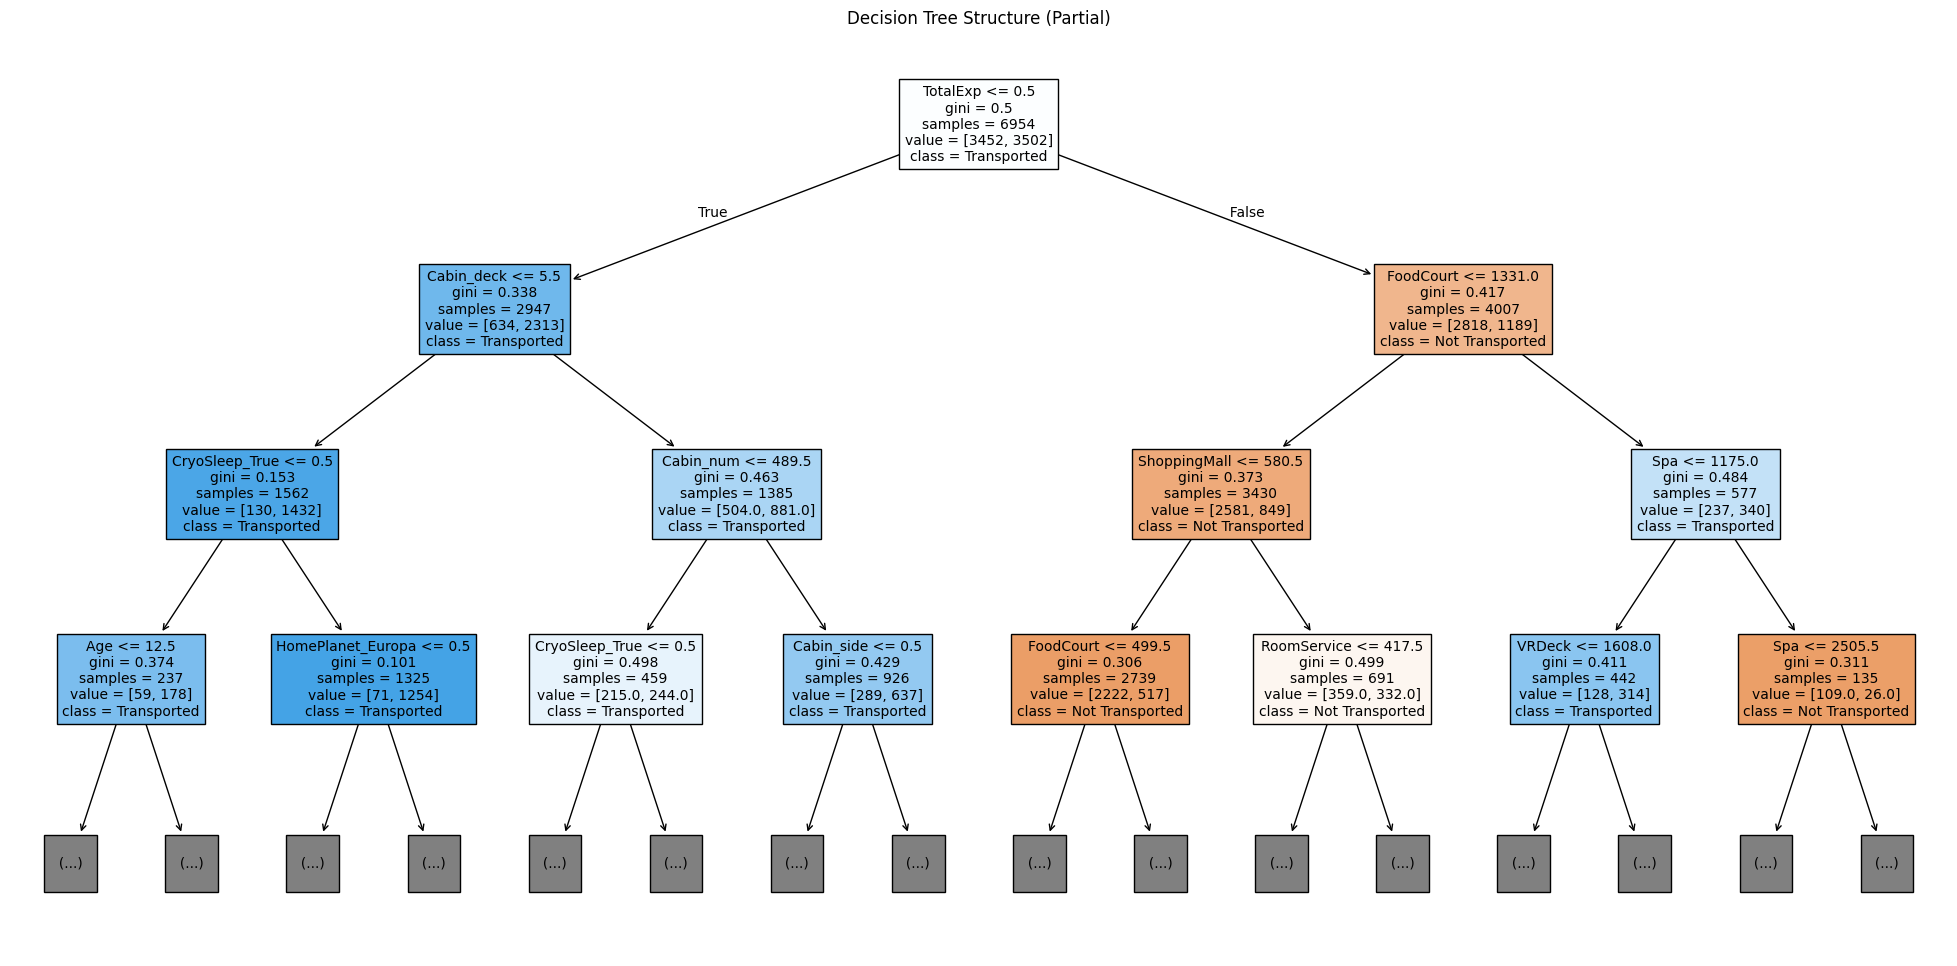

In [25]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. モデルの作成
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# 2. 検証データで予測
dt_pred = dt_model.predict(X_val)

# 3. 評価指標
print(f"Decision Tree Accuracy: {accuracy_score(y_val, dt_pred):.4f}")
print("\n--- 特徴量の重要度 (Top 5) ---")
dt_importance = pd.DataFrame({'Feature': X.columns, 'Importance': dt_model.feature_importances_})
print(dt_importance.sort_values(by='Importance', ascending=False).head(5))

# 4. 木の構造を可視化（最初の3層分だけ）
plt.figure(figsize=(25, 12))
plot_tree(dt_model,
          feature_names=X.columns,
          class_names=['Not Transported', 'Transported'],
          filled=True,
          max_depth=3,
          fontsize=10)
plt.title('Decision Tree Structure (Partial)')
plt.show()

Random Forest Accuracy: 0.8016

--- 特徴量の重要度 (Top 10) ---
           Feature  Importance
7        Cabin_num    0.121949
13        TotalExp    0.107152
0              Age    0.092356
4              Spa    0.079342
9       FamilySize    0.071677
2        FoodCourt    0.069171
1      RoomService    0.068088
5           VRDeck    0.058706
3     ShoppingMall    0.056544
19  CryoSleep_True    0.056198


/tmp/ipykernel_10394/1806705090.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=rf_importance, palette='magma')


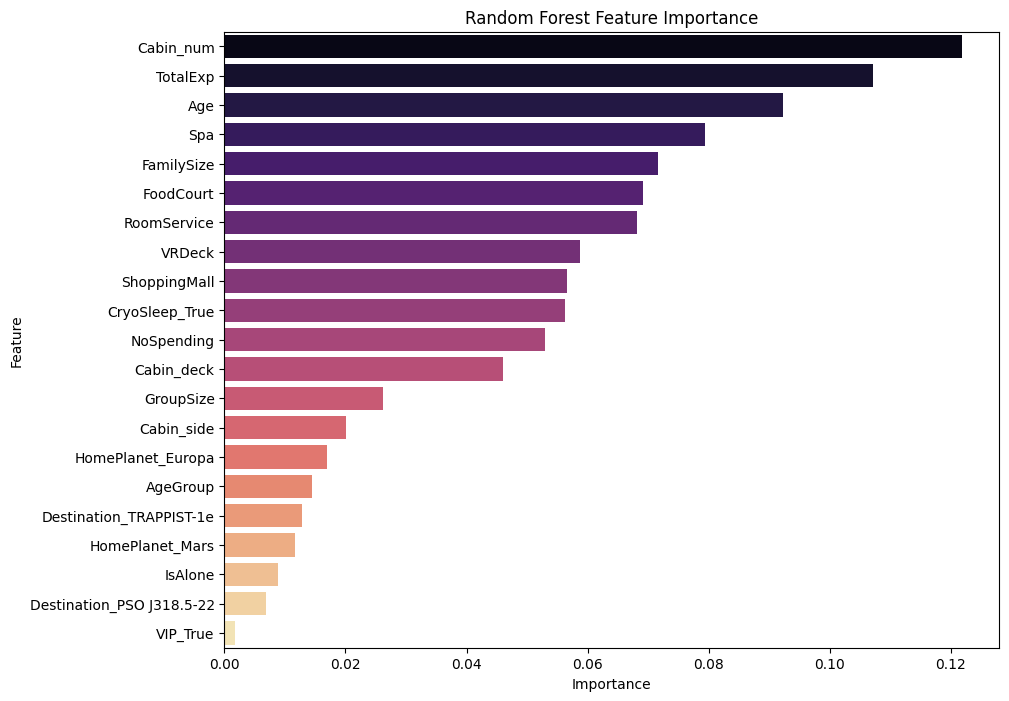

In [26]:
from sklearn.ensemble import RandomForestClassifier

# 1. モデルの作成
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 2. 検証データで予測
rf_pred = rf_model.predict(X_val)

# 3. 評価指標
print(f"Random Forest Accuracy: {accuracy_score(y_val, rf_pred):.4f}")
print("\n--- 特徴量の重要度 (Top 10) ---")
rf_importance = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model.feature_importances_})
rf_importance = rf_importance.sort_values(by='Importance', ascending=False)
print(rf_importance.head(10))

# 4. 重要度の可視化
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=rf_importance, palette='magma')
plt.title('Random Forest Feature Importance')
plt.show()

In [28]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 2.6 MB/s eta 0:00:00


[I 2026-04-29 08:01:43,884] A new study created in memory with name: no-name-8569560e-0e5d-4486-8fca-91e2ccdc17f1
[I 2026-04-29 08:01:45,002] Trial 0 finished with value: 0.8073605520414031 and parameters: {'lambda_l1': 6.293198955209127e-05, 'lambda_l2': 0.7895870143747771, 'num_leaves': 111, 'feature_fraction': 0.4981400483549661, 'bagging_fraction': 0.42249363951982394, 'bagging_freq': 1, 'min_child_samples': 34}. Best is trial 0 with value: 0.8073605520414031.
[I 2026-04-29 08:01:45,745] Trial 1 finished with value: 0.8125359401955147 and parameters: {'lambda_l1': 0.004877269896220593, 'lambda_l2': 0.008240331043138635, 'num_leaves': 179, 'feature_fraction': 0.9826122250470866, 'bagging_fraction': 0.7383516878853057, 'bagging_freq': 1, 'min_child_samples': 59}. Best is trial 1 with value: 0.8125359401955147.
[I 2026-04-29 08:01:46,670] Trial 2 finished with value: 0.81196089706728 and parameters: {'lambda_l1': 7.196982745964296e-05, 'lambda_l2': 4.374112446927661e-06, 'num_leaves':


--- Best Trial ---
Best Accuracy: 0.8246
Best Params: {'lambda_l1': 1.7719241813499964e-06, 'lambda_l2': 6.578949867984386e-08, 'num_leaves': 144, 'feature_fraction': 0.807856348097923, 'bagging_fraction': 0.9080101633970634, 'bagging_freq': 6, 'min_child_samples': 20}


/tmp/ipykernel_10394/714349493.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=lgbm_importance, palette='viridis')


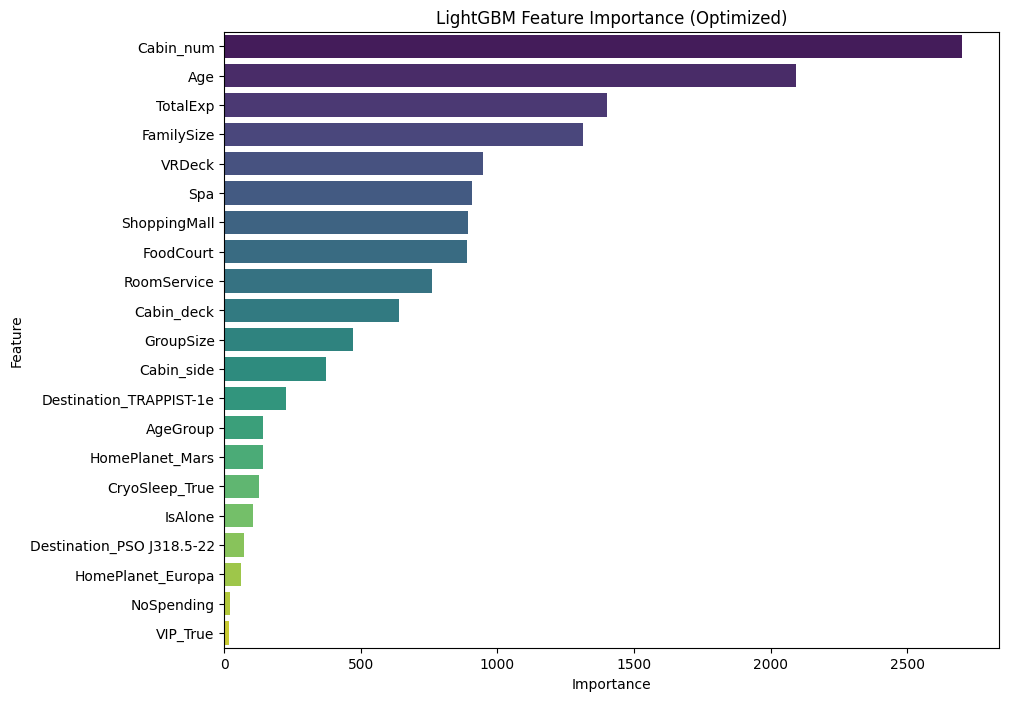

In [29]:
import lightgbm as lgb
import optuna
from sklearn.metrics import accuracy_score

# 1. Optuna用の目的関数の定義
def objective(trial):
    # 探索するパラメータの範囲を指定
    param = {
        'objective': 'binary',
        'metric': 'binary_error',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 2, 256),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
    }

    # モデルの学習
    gbm = lgb.LGBMClassifier(**param)
    gbm.fit(X_train, y_train)

    # 予測と精度計算
    preds = gbm.predict(X_val)
    accuracy = accuracy_score(y_val, preds)
    return accuracy

# 2. 最適化の実行
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50) # 50回試行

print('\n--- Best Trial ---')
print(f'Best Accuracy: {study.best_value:.4f}')
print(f'Best Params: {study.best_params}')

# 3. 最良のパラメータで最終モデルを学習
best_model = lgb.LGBMClassifier(**study.best_params)
best_model.fit(X_train, y_train)

# 4. 最終評価と重要度の可視化
lgbm_pred = best_model.predict(X_val)
lgbm_importance = pd.DataFrame({'Feature': X.columns, 'Importance': best_model.feature_importances_})
lgbm_importance = lgbm_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=lgbm_importance, palette='viridis')
plt.title('LightGBM Feature Importance (Optimized)')
plt.show()